# Modeling

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
import re
%matplotlib inline

In [2]:
df_train = pd.read_csv('./data/train_new.csv')
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


In [67]:
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ''
df_train['Title'] = df_train.Name.apply(get_title)
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr


In [71]:
df_train.Title.value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

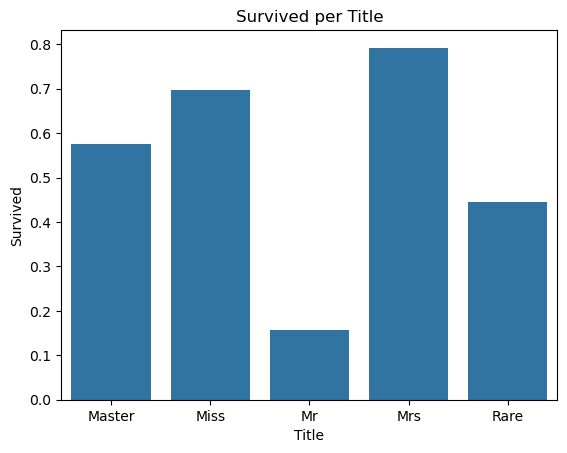

In [198]:
tt_sur_mean = df_train.groupby('Title')['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x = 'Title', y = 'Survived', data = tt_sur_mean)
plt.title('Survived per Title')
plt.show()

In [94]:
rare_map = list(df_train.Title.value_counts().keys())[4:]
df_train.Title = df_train.Title.replace(rare_map, 'Rare')

In [188]:
df_train['FamilySize'] = df_train['SibSp'] + df_train['Parch'] + 1
df_train['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

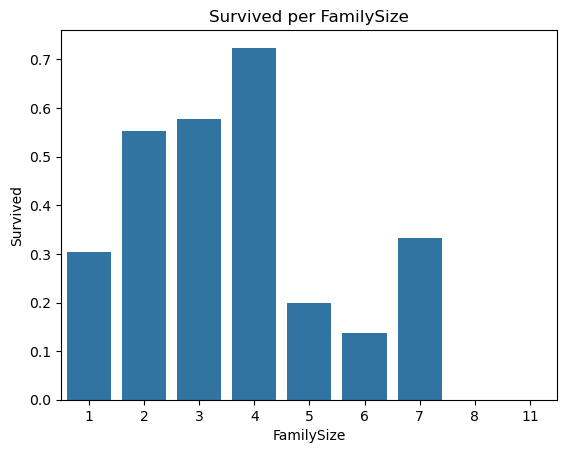

In [195]:
fs_sur_mean = df_train.groupby('FamilySize')['Survived'].mean().reset_index()
plt.figure()
sns.barplot(x='FamilySize', y='Survived', data=fs_sur_mean)
plt.title('Survived per FamilySize')
plt.show()

In [199]:
bins = [0, 1, 4, 12]
labels = ['Single', 'Small', 'Big']

df_train['FamilyCategory'] = pd.cut(
    df_train['FamilySize'], 
    bins=bins, 
    labels=labels, 
    right=True,
    include_lowest=True
)

df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCategory
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,2,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,Single
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,2,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,Single


In [200]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilyCategory']
target = 'Survived'
X = df_train[features]
y = df_train[target]

In [96]:
y.value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42) 

In [203]:
numerical_features = X_train.select_dtypes(include = ['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include = ['object', 'category']).columns.tolist()

In [204]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), categorical_features)
    ]
)

In [205]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state = 42))
])

In [206]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

In [207]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [208]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [50, 100]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [209]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



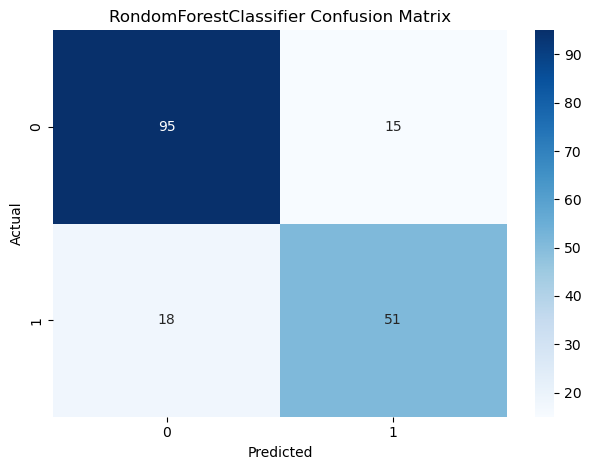

In [210]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('RondomForestClassifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [211]:
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .get_feature_names_out(categorical_features))

In [212]:
importance_df = pd.DataFrame({
    'Features' : feature_names,
    'Importance' : model.best_estimator_['classifier'].feature_importances_
}).sort_values(by = 'Importance')

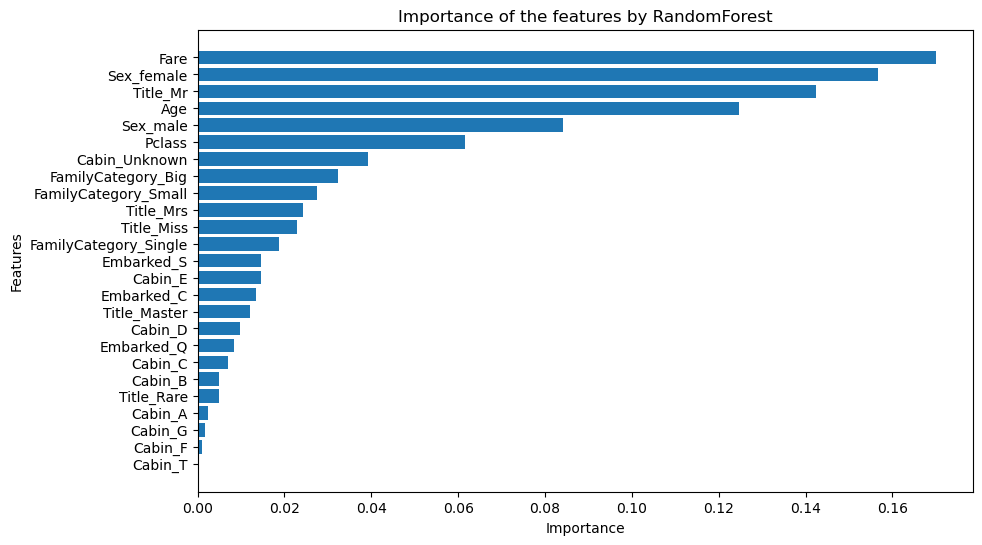

In [213]:
plt.figure(figsize = (10, 6))
plt.barh(importance_df['Features'], importance_df['Importance'])
plt.title('Importance of the features by RandomForest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [214]:
pipeline.set_params(classifier = LogisticRegression(class_weight='balanced', random_state = 42))
model.estimator = pipeline
param_grid = [
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100], 
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'liblinear'],
        'classifier__max_iter': [500, 1000] 
    },
    {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [500, 1000] 
    }
]
model.param_grid = param_grid
model.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=lbfgs; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=0.001, classifier__max_iter=500,

C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.3s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.1s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.1s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classif

C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.6s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.6s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.6s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=10, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s
[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.3s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=saga; total time=   0.2s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s
[CV] END classifier__C=100, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=saga; total time=   0.5s


C:\Users\zxdr5\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [0.001, 0.01, ...], 'classifier__max_iter': [500, 1000], 'classifier__penalty': ['l2'], 'classifier__solver': ['lbfgs', 'liblinear']}, {'classifier__C': [0.001, 0.01, ...], 'classifier__max_iter': [500, 1000], 'classifier__penalty': ['l1'], 'classifier__solver': ['liblinear', 'saga']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [215]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85       110
           1       0.76      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



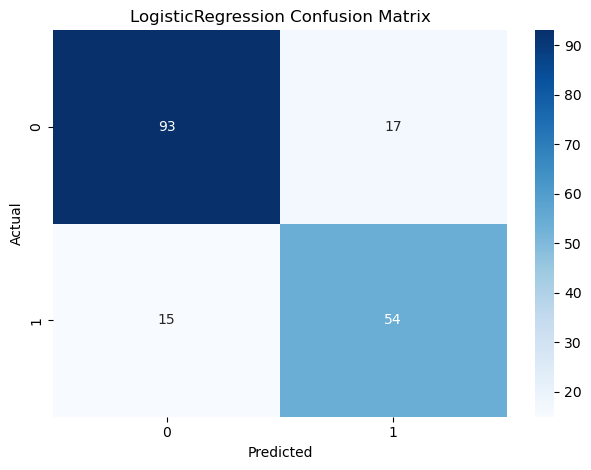

In [216]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')
plt.title('LogisticRegression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [217]:
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                                                .named_transformers_['cat']
                                                                .get_feature_names_out(categorical_features))
coefficient_df = pd.DataFrame({
    'Features' : feature_names,
    'Coefficient' : model.best_estimator_['classifier'].coef_[0]
}).sort_values(by = 'Coefficient')

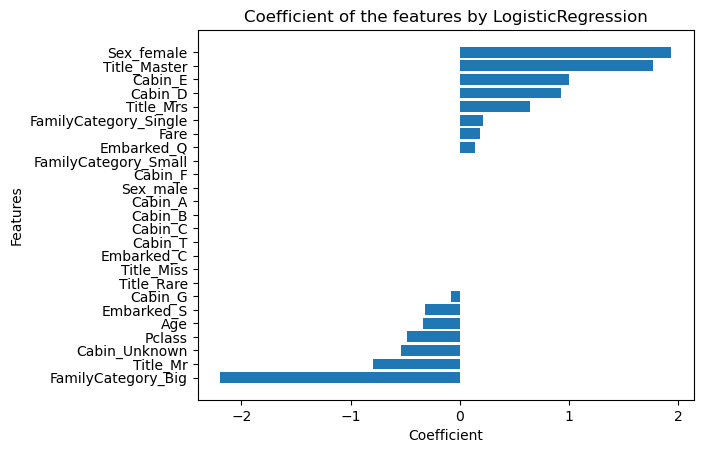

In [218]:
plt.figure()
plt.barh(coefficient_df['Features'], coefficient_df['Coefficient'])
plt.title('Coefficient of the features by LogisticRegression')
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.show()

In [230]:
pipeline.set_params(classifier = XGBClassifier(scale_pos_weight=1.605, random_state = 42))
param_grid = {
    'classifier__n_estimators': [160, 180, 200],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.05, 0.1, 0.15],
    'classifier__gamma': [0, 0.1] 
}
model.estimator = pipeline
model.param_grid = param_grid
model.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=160; total time=   0.1s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=160; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=160; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=160; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=160; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=180; total time=   0.0s
[CV] END classifier__gamma=0, classifier__learning_rate=0.05, classifier__max_depth=3, classifier__n_estimators=180; total

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'classifier__gamma': [0, 0.1], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [160, 180, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [231]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       110
           1       0.74      0.80      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [232]:
xgb_model = model.best_estimator_

In [233]:
pipeline.set_params(classifier = LogisticRegression(class_weight = 'balanced', random_state = 42))
param_grid = [
    {
        'classifier__C': [1, 2, 3, 4, 5],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear'],
        'classifier__max_iter': [500, 1000] 
    }
]
model.estimator = pipeline
model.param_grid = param_grid
model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=500, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__C=1, classifier__max_iter=1000, classifie

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'classifier__C': [1, 2, ...], 'classifier__max_iter': [500, 1000], 'classifier__penalty': ['l1'], 'classifier__solver': ['liblinear']}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [234]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       110
           1       0.75      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [235]:
lr_model = model.best_estimator_

In [246]:
estimators = [
    ('lr', lr_model),
    ('xgb', xgb_model)
]
soft_voting_clf = VotingClassifier(
    estimators = estimators,
    voting = 'soft',
    weights = [0.5, 0.5],
    n_jobs = -1
)
soft_voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('xgb', ...)]"
,voting,'soft'
,weights,"[0.5, 0.5]"
,n_jobs,-1
,flatten_transform,True
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [247]:
y_pred = soft_voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85       110
           1       0.75      0.80      0.77        69

    accuracy                           0.82       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



In [254]:
df_test = pd.read_csv('./data/test_new.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


In [255]:
df_test['Title'] = df_test['Name'].apply(get_title)
df_test.Title.value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [256]:
rare_map = list(df_test.Title.keys())[4:]
df_test.Title = df_test.Title.replace(rare_map, 'Rare')

In [257]:
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1
df_test['FamilySize'].value_counts()

FamilySize
1     253
2      74
3      57
4      14
5       7
7       4
11      4
6       3
8       2
Name: count, dtype: int64

In [258]:
df_test['FamilyCategory'] = pd.cut(
    df_test['FamilySize'],
    bins = bins,
    labels = labels,
    right = True,
    include_lowest = True
)

In [259]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilyCategory']
X = df_test[features]

In [260]:
final_y_pred = soft_voting_clf.predict(X)

In [261]:
submission_df = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': final_y_pred
})

submission_df.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [262]:
submission_df.to_csv('submission.csv', index=False)